<a href="https://colab.research.google.com/github/khattarj/intro-ml-course-winter2026/blob/main/HAD5016_Datathon_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing dataset and packages**

In [1]:
# Importing dataset
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv("drive/My Drive/Colab Notebooks/Datathon #4 - mhealth Dataset - HAD7001.csv") # Change as needed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data head
data.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


# **Data Configurations**

**1. Removing subject 9 and collapsing the activity column into sedentary vs not sedentary**

In [2]:
# Remove rows where subject is 'subject9'
data2 = data[data.subject != 'subject9']

In [ ]:
# Check value counts for activity
data2.Activity.value_counts()

,count
Activity,
0,707122
1,24576
2,24576
3,24576
4,24576
9,24576
5,24576
11,24576
10,24576


In [3]:
# Collapse activity
data3 = data2.copy()

# Condition
data3.loc[:, 'Activity'] = (data2['Activity'] >= 4).astype(int)

# Check the frequency
data3.Activity.value_counts()

,count
Activity,
0,780850
1,201423


In [ ]:
# Check type of variables
data3.dtypes

,0
alx,float64
aly,float64
alz,float64
glx,float64
gly,float64
glz,float64
arx,float64
ary,float64
arz,float64
grx,float64


# **Data Exploration**

In [ ]:
print (data3.shape)

(982273, 14)


In [ ]:
# Check missing data
check_missing_data = data3.isnull().sum()
print (check_missing_data)

alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64


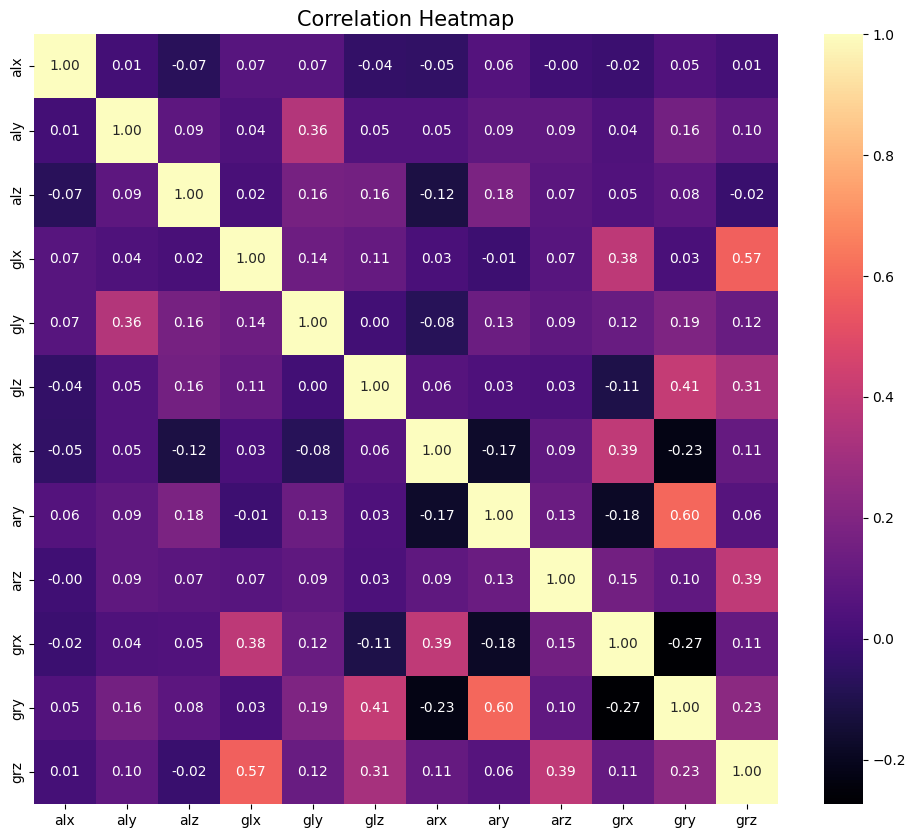

In [ ]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = data3.select_dtypes(include=['float64'])
corr_matrix = numerical_features.corr()

# Plot the updated correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='magma')
plt.title('Correlation Heatmap', fontsize=15)
plt.show()


# **Machine Learning - Pre-processing**

In [4]:
df = data3.copy()
df = df.rename(columns={'subject': 'patient_nbr'})

**1. Splitting into training and testing data**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Grouping by 'patient_nbr' and creating a list of dataframes, one per group
grouped = df.groupby('patient_nbr')
grouped_dfs = [group for _, group in grouped]

# Splitting the groups into training and test sets with an 80:20 ratio
train_groups, test_groups = train_test_split(grouped_dfs, test_size=0.2, random_state=42)

# Reassembling the training and test datasets from the groups
train_df = pd.concat(train_groups)
test_df = pd.concat(test_groups)

# Displaying the shape of the training and test sets
train_df_shape = train_df.shape
test_df_shape = test_df.shape

train_df_shape, test_df_shape

((753408, 14), (228865, 14))

**2. Scaling the data**

In [6]:
from sklearn.preprocessing import StandardScaler

# Identifying numerical columns which we will normalize (excluding 'subject' and 'Activity')
numerical_columns = train_df.select_dtypes(include=['int64', 'float64', 'object']).columns.tolist()
numerical_columns.remove('patient_nbr')
numerical_columns.remove('Activity')

# Print variables in numerical_columns
print (numerical_columns)

['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx', 'gry', 'grz']


In [7]:
# Initializing the StandardScaler
scaler = StandardScaler()

# Fitting the scaler to the training data and transforming both training and test data
train_df[numerical_columns] = scaler.fit_transform(train_df[numerical_columns])
test_df[numerical_columns] = scaler.transform(test_df[numerical_columns])

# Checking the first few rows of the normalized training data
train_df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,patient_nbr
0,0.214821,-0.022355,0.309939,0.244241,-0.668159,-1.036175,-1.098917,0.233330,-0.594683,-0.335191,-1.016340,-0.471094,0,subject1
1,0.267516,0.023418,0.319902,0.207517,-0.662733,-1.028975,-1.094306,0.278958,-0.636633,-0.335191,-1.016340,-0.471094,0,subject1
2,0.272975,0.009010,0.319384,0.207517,-0.662733,-1.028975,-1.069191,0.286484,-0.572206,-0.335191,-1.016340,-0.471094,0,subject1
3,0.213911,0.042315,0.294847,0.207517,-0.662733,-1.028975,-1.094388,0.279577,-0.548748,-0.349689,-1.012564,-0.486675,0,subject1
4,0.275237,0.052309,0.324983,0.207517,-0.662733,-1.028975,-1.109395,0.309677,-0.538585,-0.349689,-1.012564,-0.486675,0,subject1


**3. Sequencing the training dataset**

In [8]:
# Sequencing the training dataset

def Create_ID_column_for_participant_and_activity(train_df, patient_nbr:str, Activity:str, count_col='activity_participant_ID'):
    """
    This function assigns a unique identifier to each participant-activity sequence in the dataframe.
    Every time a participant switches activities, a new ID is assigned in the specified column.

    This assumes that the data is in chronological order and accounts for cases where a participant
    engages in multiple activities over time (e.g., switching from activity 0 to activity 1, back to 0,
    and then to activity 2). Each transition triggers a new ID to be created, aiding in grouping and
    sequence generation.

    Parameters:
        df (pd.DataFrame): The input dataframe.
        participant_ID (str): Column name representing the participant identifier.
        activity (str): Column name representing the activity label.
        count_col (str, optional): Name of the new column to store sequence IDs. Default is 'activity_participant_ID'.

    Returns:
        pd.DataFrame: The dataframe with an added column assigning unique sequence IDs.
    """
    train_df[count_col] = 0  # initialize the new ID column with 0

    # initialize variables to store last values
    last_subject = None
    last_activity = None
    count = 0

    # loop through the rows of the df
    for index, row in train_df.iterrows():
        current_subject = row[patient_nbr]
        current_activity = row[Activity]

        # check if the values are the same as the last row
        if current_subject == last_subject and current_activity == last_activity:
            train_df.at[index, count_col] = count
        else:
            count += 1
            train_df.at[index, count_col] = count

        # update the last values
        last_subject = current_subject
        last_activity = current_activity

    return train_df

In [9]:
train_df = Create_ID_column_for_participant_and_activity(train_df, 'patient_nbr', 'Activity')

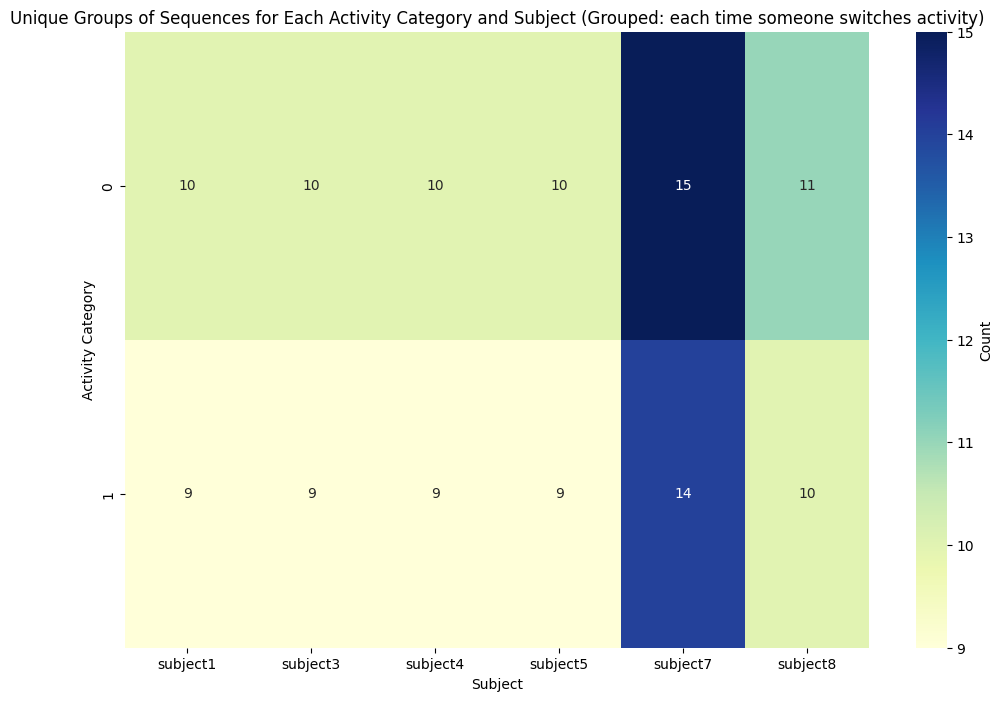

In [ ]:
# Visualize groups (by subject and activity)
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = train_df.groupby(['Activity', 'patient_nbr'])['activity_participant_ID'].nunique().unstack()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu', cbar_kws={'label': 'Count'})
plt.title('Unique Groups of Sequences for Each Activity Category and Subject (Grouped: each time someone switches activity)')
plt.xlabel('Subject')
plt.ylabel('Activity Category')
plt.show()

In [ ]:
# Check overall frequency of activity in the training set
train_df['Activity'].value_counts()

,count
Activity,
0,601290
1,152118


In [ ]:
# Check overall frequency of activity in the 126 sequences
activity_frequency_sequences = pd.Series(targets).value_counts()
print(activity_frequency_sequences)


0    66
1    60
Name: count, dtype: int64


In [17]:
# Padding sequences for the training set based on 'activity_participant_ID'
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Determine the maximum sequence length based on 'activity_participant_ID'
sequence_lengths = train_df.groupby('activity_participant_ID').size()
max_sequence_length = 50 # Changed to 500 as per user request

# List to store sequences (numerical features) and their corresponding activity labels
sequences = []
targets = []

# Group by 'activity_participant_ID' and extract numerical features and the activity label
for activity_id, group in train_df.groupby('activity_participant_ID'):
    sequences.append(group[numerical_columns].values)
    # Assuming the activity label is constant within each 'activity_participant_ID' group
    targets.append(group['Activity'].iloc[0])

# Pad the sequences to the maximum length, and truncate if longer
# Use dtype='float32' for compatibility with most deep learning frameworks
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post', dtype='float32')

# Convert targets to a numpy array
targets = np.array(targets)

print(f"Shape of padded_sequences: {padded_sequences.shape}")
print(f"Shape of targets: {targets.shape}")
print(f"Max sequence length (based on activity_participant_ID): {max_sequence_length}")

Shape of padded_sequences: (126, 50, 12)
Shape of targets: (126,)
Max sequence length (based on activity_participant_ID): 50


In [ ]:
# Check max sequence length
sequence_lengths = train_df.groupby('activity_participant_ID').size()
max_sequence_length = sequence_lengths.max()
max_sequence_length
describe_sequence_lengths = sequence_lengths.describe()
describe_sequence_lengths

,0
count,126.000000
mean,5979.428571
std,8717.074995
min,512.000000
25%,2560.000000
50%,3072.000000
75%,5632.000000
max,51968.000000


**4. Sequencing the test set**

In [11]:
# Sequencing the test dataset

def Create_ID_column_for_participant_and_activity(test_df, patient_nbr:str, Activity:str, count_col='activity_participant_ID'):
    """
    This function assigns a unique identifier to each participant-activity sequence in the dataframe.
    Every time a participant switches activities, a new ID is assigned in the specified column.

    This assumes that the data is in chronological order and accounts for cases where a participant
    engages in multiple activities over time (e.g., switching from activity 0 to activity 1, back to 0,
    and then to activity 2). Each transition triggers a new ID to be created, aiding in grouping and
    sequence generation.

    Parameters:
        df (pd.DataFrame): The input dataframe.
        participant_ID (str): Column name representing the participant identifier.
        activity (str): Column name representing the activity label.
        count_col (str, optional): Name of the new column to store sequence IDs. Default is 'activity_participant_ID'.

    Returns:
        pd.DataFrame: The dataframe with an added column assigning unique sequence IDs.
    """
    test_df[count_col] = 0  # initialize the new ID column with 0

    # initialize variables to store last values
    last_subject = None
    last_activity = None
    count = 0

    # loop through the rows of the df
    for index, row in test_df.iterrows():
        current_subject = row[patient_nbr]
        current_activity = row[Activity]

        # check if the values are the same as the last row
        if current_subject == last_subject and current_activity == last_activity:
            test_df.at[index, count_col] = count
        else:
            count += 1
            test_df.at[index, count_col] = count

        # update the last values
        last_subject = current_subject
        last_activity = current_activity

    return test_df

In [12]:
test_df = Create_ID_column_for_participant_and_activity(test_df, 'patient_nbr', 'Activity')

In [18]:
# Padding sequences for the test set based on 'activity_participant_ID'
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Determine the maximum sequence length based on 'activity_participant_ID'
sequence_lengths = test_df.groupby('activity_participant_ID').size()
max_sequence_length = 50

# List to store sequences (numerical features) and their corresponding activity labels
sequences = []
targets_test = []

# Group by 'activity_participant_ID' and extract numerical features and the activity label
for activity_id, group in test_df.groupby('activity_participant_ID'):
    sequences.append(group[numerical_columns].values)
    # Assuming the activity label is constant within each 'activity_participant_ID' group
    targets_test.append(group['Activity'].iloc[0])

# Pad the sequences to the maximum length, and truncate if longer
# Use dtype='float32' for compatibility with most deep learning frameworks
padded_sequences_test = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post', dtype='float32')

# Convert targets to a numpy array
targets_test = np.array(targets_test)

print(f"Shape of padded_sequences: {padded_sequences_test.shape}")
print(f"Shape of targets: {targets_test.shape}")
print(f"Max sequence length (based on activity_participant_ID): {max_sequence_length}")

Shape of padded_sequences: (38, 50, 12)
Shape of targets: (38,)
Max sequence length (based on activity_participant_ID): 50


# **Machine Learning - RNN**

In [24]:
import torch as t
import torch.nn as nn
from torch.nn.functional import sigmoid, relu, tanh
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score # Import metrics

padded_sequences = np.array(padded_sequences)
targets = np.array(targets)

# Hyperparameters
input_size = padded_sequences.shape[2]
hidden_size = 256  # Number of hidden units in RNN
num_classes = 1  # For single output neuron with sigmoid
epochs = 50
learning_rate = 0.001
batch_size = 64 # This batch_size will be used for training
landa = 0.001  # Regularization term (lambda)

# Data preparation

# Re-generate targets for training data to ensure correct length
# This is added as a fix for the IndexError where 'targets' was found to be of incorrect length (38 instead of 126)
# This logic normally happens in cell OqVZ95lZi4SU, but the variable appears to have been overwritten.
sequences_train_regen = []
targets_train_regen = []
for activity_id, group in train_df.groupby('activity_participant_ID'):
    sequences_train_regen.append(group[numerical_columns].values)
    targets_train_regen.append(group['Activity'].iloc[0])
targets = np.array(targets_train_regen)

train_dataset = TensorDataset(t.tensor(padded_sequences, dtype=t.float32), t.tensor(targets, dtype=t.float32).unsqueeze(1)) # Target needs to be float32 for BCEWithLogitsLoss
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True);

test_dataset = TensorDataset(t.tensor(padded_sequences_test, dtype=t.float32), t.tensor(targets_test, dtype=t.float32).unsqueeze(1)) # Target needs to be float32 for BCEWithLogitsLoss
# Adjust batch size for the test set to avoid indexing issues with very small datasets
test_batch_size = len(test_dataset) # Set test batch size to the full size of the test dataset
test_data_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.RNN(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)  # Add dropout between RNN layers
rnn_layer2 = nn.RNN(hidden_size, hidden_size, batch_first=True)
dropout2 = nn.Dropout(0.5)  # Add dropout between RNN layers
fc_layer1 = nn.Linear(hidden_size, hidden_size // 2)  # Additional fully connected layer
fc_layer2 = nn.Linear(hidden_size // 2, num_classes)  # Final output layer (1 for sigmoid)

# Dropout layer
dropout_fc = nn.Dropout(0.2)  # Add dropout between fully connected layers

# Activation function
relu = nn.ReLU()

# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss() # Changed to BCEWithLogitsLoss for sigmoid output
# optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)
# optimizer = Adam(list(rnn_layer1.parameters())+ list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

# Lists to store accuracies and losses
all_loss = []
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Initialize lists to store metrics
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = [] # List to store AUC scores

# Training loop
for epoch in range(epochs):

    if epoch % 10 == 0:
        learning_rate *= 0.9  # Learning rate scheduling

    optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

    per_epoch_loss_list = []
    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)  # Apply dropout between RNN layers
        out, _ = rnn_layer2(out)
        out = dropout2(out)  # Apply dropout between RNN layers
        out = out[:, -1, :]  # Get the last output of the sequence
        out = relu(fc_layer1(out))  # Apply activation function after first fully connected layer
        out = dropout_fc(out)  # Apply dropout between fully connected layers
        out = fc_layer2(out) # Output logits

        # Regularization
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # loss = loss_fn(out, Y) + landa * l2_term
        loss = loss_fn(out, Y)
        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # max_iter -=1
        # if max_iter == 0:
        #     break
    all_loss += per_epoch_loss_list

    # Evaluation on training and validation data
    rnn_layer1.eval()
    rnn_layer2.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            out, _ = rnn_layer2(out)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            predicted = (t.sigmoid(out) > 0.5).float() # Sigmoid and threshold for prediction
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        val_predictions = []
        val_targets = []
        val_probabilities = [] # Store probabilities for AUC
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            out, _ = rnn_layer2(out)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            val_probs_epoch = t.sigmoid(out) # Get probabilities
            predicted = (val_probs_epoch > 0.5).float() # Binary predictions
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
            val_predictions.extend(predicted.cpu().numpy().flatten()) # Flatten for sklearn metrics
            val_targets.extend(Y.cpu().numpy().flatten()) # Flatten for sklearn metrics
            val_probabilities.extend(val_probs_epoch.cpu().numpy().flatten()) # Store probabilities

        validation_accuracy = 100 * validation_correct / validation_total

        # Calculate and store precision, recall, f1-score for validation data
        precision = precision_score(val_targets, val_predictions, average='weighted', zero_division=0)
        recall = recall_score(val_targets, val_predictions, average='weighted', zero_division=0)
        f1 = f1_score(val_targets, val_predictions, average='weighted', zero_division=0)
        auc = roc_auc_score(val_targets, val_probabilities) # Calculate AUC

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc) # Store AUC

        # Print accuracy for the current epoch
        print(f'Epoch {epoch}/{epochs} ---> Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {validation_accuracy:.2f}%, AUC: {auc:.2f}')

        # Append accuracy values to lists
        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    # Calculate and append the average loss for the epoch
    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    # Set the model back to train mode
    rnn_layer1.train()
    rnn_layer2.train()
    fc_layer1.train()
    fc_layer2.train()

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1 = np.mean(f1_scores)
avg_auc = np.mean(auc_scores) # Calculate average AUC
avg_validation_accuracy = np.mean(validation_accuracy_list) # Calculate average validation accuracy
avg_train_accuracy = np.mean(train_accuracy_list) # Calculate average train accuracy

print(f'\n--- Training Summary ---\n')
print(f'Average Train Accuracy: {avg_train_accuracy:.2f}%')
print(f'Average Validation Accuracy: {avg_validation_accuracy:.2f}%')
print(f'Average Precision: {avg_precision:.2f}')
print(f'Average Recall: {avg_recall:.2f}')
print(f'Average F1-score: {avg_f1:.2f}')
print(f'Average AUC: {avg_auc:.2f}')

Epoch 0/50 ---> Train Accuracy: 56.35%, Validation Accuracy: 60.53%, AUC: 0.68
Epoch 1/50 ---> Train Accuracy: 57.94%, Validation Accuracy: 63.16%, AUC: 0.73
Epoch 2/50 ---> Train Accuracy: 61.11%, Validation Accuracy: 68.42%, AUC: 0.74
Epoch 3/50 ---> Train Accuracy: 63.49%, Validation Accuracy: 57.89%, AUC: 0.69
Epoch 4/50 ---> Train Accuracy: 61.11%, Validation Accuracy: 60.53%, AUC: 0.68
Epoch 5/50 ---> Train Accuracy: 65.08%, Validation Accuracy: 60.53%, AUC: 0.68
Epoch 6/50 ---> Train Accuracy: 62.70%, Validation Accuracy: 57.89%, AUC: 0.66
Epoch 7/50 ---> Train Accuracy: 63.49%, Validation Accuracy: 63.16%, AUC: 0.64
Epoch 8/50 ---> Train Accuracy: 65.08%, Validation Accuracy: 55.26%, AUC: 0.63
Epoch 9/50 ---> Train Accuracy: 65.08%, Validation Accuracy: 55.26%, AUC: 0.63
Epoch 10/50 ---> Train Accuracy: 67.46%, Validation Accuracy: 65.79%, AUC: 0.68
Epoch 11/50 ---> Train Accuracy: 63.49%, Validation Accuracy: 57.89%, AUC: 0.69
Epoch 12/50 ---> Train Accuracy: 65.87%, Validatio

In [25]:
print(f"Average Precision: {avg_precision:.3f}")
print(f"Average Recall: {avg_recall:.3f}")
print(f"Average F1-score: {avg_f1:.3f}")
print(f"Average AUC: {avg_auc:.3f}")

Average Precision: 0.629
Average Recall: 0.621
Average F1-score: 0.614
Average AUC: 0.672


# **Machine Learning - RNN**

In [ ]:
import torch as t
import torch.nn as nn
from torch.nn.functional import sigmoid, relu, tanh
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score # Import metrics

padded_sequences = np.array(padded_sequences)
targets = np.array(targets)

# Hyperparameters
input_size = padded_sequences.shape[2]
hidden_size = 256  # Number of hidden units in RNN
num_classes = 1  # For single output neuron with sigmoid
epochs = 50
learning_rate = 0.001
batch_size = 64 # This batch_size will be used for training
landa = 0.001  # Regularization term (lambda)

# Data preparation

# Re-generate targets for training data to ensure correct length
# This is added as a fix for the IndexError where 'targets' was found to be of incorrect length (38 instead of 126)
# This logic normally happens in cell OqVZ95lZi4SU, but the variable appears to have been overwritten.
sequences_train_regen = []
targets_train_regen = []
for activity_id, group in train_df.groupby('activity_participant_ID'):
    sequences_train_regen.append(group[numerical_columns].values)
    targets_train_regen.append(group['Activity'].iloc[0])
targets = np.array(targets_train_regen)

train_dataset = TensorDataset(t.tensor(padded_sequences, dtype=t.float32), t.tensor(targets, dtype=t.float32).unsqueeze(1)) # Target needs to be float32 for BCEWithLogitsLoss
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True);

test_dataset = TensorDataset(t.tensor(padded_sequences_test, dtype=t.float32), t.tensor(targets_test, dtype=t.float32).unsqueeze(1)) # Target needs to be float32 for BCEWithLogitsLoss
# Adjust batch size for the test set to avoid indexing issues with very small datasets
test_batch_size = len(test_dataset) # Set test batch size to the full size of the test dataset
test_data_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# RNN layers and additional fully connected layer
rnn_layer1 = nn.RNN(input_size, hidden_size, batch_first=True)
dropout1 = nn.Dropout(0.5)  # Add dropout between RNN layers
rnn_layer2 = nn.RNN(hidden_size, hidden_size, batch_first=True)
dropout2 = nn.Dropout(0.5)  # Add dropout between RNN layers
fc_layer1 = nn.Linear(hidden_size, hidden_size // 2)  # Additional fully connected layer
fc_layer2 = nn.Linear(hidden_size // 2, num_classes)  # Final output layer (1 for sigmoid)

# Dropout layer
dropout_fc = nn.Dropout(0.2)  # Add dropout between fully connected layers

# Activation function
relu = nn.ReLU()

# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss() # Changed to BCEWithLogitsLoss for sigmoid output
# optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)
# optimizer = Adam(list(rnn_layer1.parameters())+ list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

# Lists to store accuracies and losses
all_loss = []
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Initialize lists to store metrics
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = [] # List to store AUC scores

# Training loop
for epoch in range(epochs):

    if epoch % 10 == 0:
        learning_rate *= 0.9  # Learning rate scheduling

    optimizer = Adam(list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters()), lr=learning_rate)

    per_epoch_loss_list = []
    for X, Y in train_data_loader:
        # Forward pass through layers
        out, _ = rnn_layer1(X)
        out = dropout1(out)  # Apply dropout between RNN layers
        out, _ = rnn_layer2(out)
        out = dropout2(out)  # Apply dropout between RNN layers
        out = out[:, -1, :]  # Get the last output of the sequence
        out = relu(fc_layer1(out))  # Apply activation function after first fully connected layer
        out = dropout_fc(out)  # Apply dropout between fully connected layers
        out = fc_layer2(out) # Output logits

        # Regularization
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(rnn_layer2.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # l2_term = sum([(w ** 2).sum() for w in list(rnn_layer1.parameters()) + list(fc_layer1.parameters()) + list(fc_layer2.parameters())])
        # loss = loss_fn(out, Y) + landa * l2_term
        loss = loss_fn(out, Y)
        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # max_iter -=1
        # if max_iter == 0:
        #     break
    all_loss += per_epoch_loss_list

    # Evaluation on training and validation data
    rnn_layer1.eval()
    rnn_layer2.eval()
    fc_layer1.eval()
    fc_layer2.eval()

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out, _ = rnn_layer1(X)
            out, _ = rnn_layer2(out)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            predicted = (t.sigmoid(out) > 0.5).float() # Sigmoid and threshold for prediction
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        val_predictions = []
        val_targets = []
        val_probabilities = [] # Store probabilities for AUC
        for X, Y in test_data_loader:
            out, _ = rnn_layer1(X)
            out, _ = rnn_layer2(out)
            out = out[:, -1, :]
            out = relu(fc_layer1(out))
            out = fc_layer2(out)
            val_probs_epoch = t.sigmoid(out) # Get probabilities
            predicted = (val_probs_epoch > 0.5).float() # Binary predictions
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
            val_predictions.extend(predicted.cpu().numpy().flatten()) # Flatten for sklearn metrics
            val_targets.extend(Y.cpu().numpy().flatten()) # Flatten for sklearn metrics
            val_probabilities.extend(val_probs_epoch.cpu().numpy().flatten()) # Store probabilities

        validation_accuracy = 100 * validation_correct / validation_total

        # Calculate and store precision, recall, f1-score for validation data
        precision = precision_score(val_targets, val_predictions, average='weighted', zero_division=0)
        recall = recall_score(val_targets, val_predictions, average='weighted', zero_division=0)
        f1 = f1_score(val_targets, val_predictions, average='weighted', zero_division=0)
        auc = roc_auc_score(val_targets, val_probabilities) # Calculate AUC

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc) # Store AUC

        # Print accuracy for the current epoch
        print(f'Epoch {epoch}/{epochs} ---> Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {validation_accuracy:.2f}%, AUC: {auc:.2f}')

        # Append accuracy values to lists
        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    # Calculate and append the average loss for the epoch
    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

    # Set the model back to train mode
    rnn_layer1.train()
    rnn_layer2.train()
    fc_layer1.train()
    fc_layer2.train()

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1 = np.mean(f1_scores)
avg_auc = np.mean(auc_scores) # Calculate average AUC
avg_validation_accuracy = np.mean(validation_accuracy_list) # Calculate average validation accuracy
avg_train_accuracy = np.mean(train_accuracy_list) # Calculate average train accuracy

print(f'\n--- Training Summary ---\n')
print(f'Average Train Accuracy: {avg_train_accuracy:.2f}%')
print(f'Average Validation Accuracy: {avg_validation_accuracy:.2f}%')
print(f'Average Precision: {avg_precision:.2f}')
print(f'Average Recall: {avg_recall:.2f}')
print(f'Average F1-score: {avg_f1:.2f}')
print(f'Average AUC: {avg_auc:.2f}')

Epoch 0/50 ---> Train Accuracy: 50.79%, Validation Accuracy: 50.00%, AUC: 0.65
Epoch 1/50 ---> Train Accuracy: 52.38%, Validation Accuracy: 52.63%, AUC: 0.65
Epoch 2/50 ---> Train Accuracy: 52.38%, Validation Accuracy: 50.00%, AUC: 0.60
Epoch 3/50 ---> Train Accuracy: 69.84%, Validation Accuracy: 65.79%, AUC: 0.65
Epoch 4/50 ---> Train Accuracy: 69.84%, Validation Accuracy: 65.79%, AUC: 0.65
Epoch 5/50 ---> Train Accuracy: 52.38%, Validation Accuracy: 52.63%, AUC: 0.70
Epoch 6/50 ---> Train Accuracy: 69.05%, Validation Accuracy: 65.79%, AUC: 0.62
Epoch 7/50 ---> Train Accuracy: 52.38%, Validation Accuracy: 52.63%, AUC: 0.69
Epoch 8/50 ---> Train Accuracy: 50.79%, Validation Accuracy: 50.00%, AUC: 0.63
Epoch 9/50 ---> Train Accuracy: 70.63%, Validation Accuracy: 60.53%, AUC: 0.65
Epoch 10/50 ---> Train Accuracy: 70.63%, Validation Accuracy: 68.42%, AUC: 0.65
Epoch 11/50 ---> Train Accuracy: 51.59%, Validation Accuracy: 50.00%, AUC: 0.47
Epoch 12/50 ---> Train Accuracy: 70.63%, Validatio

In [ ]:
print(f"Average Precision: {avg_precision:.3f}")
print(f"Average Recall: {avg_recall:.3f}")
print(f"Average F1-score: {avg_f1:.3f}")
print(f"Average AUC: {avg_auc:.3f}")

Average Precision: 0.646
Average Recall: 0.608
Average F1-score: 0.548
Average AUC: 0.650


**# Machine Learning - LSTM**

In [19]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_lstm_rate=0.5, dropout_fc_rate=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # Two stacked LSTM layers
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout_lstm1 = nn.Dropout(dropout_lstm_rate)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.dropout_lstm2 = nn.Dropout(dropout_lstm_rate)

        # Two fully connected layers
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.dropout_fc = nn.Dropout(dropout_fc_rate)
        self.fc2 = nn.Linear(hidden_size // 2, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass through first LSTM layer
        out, _ = self.lstm1(x)
        out = self.dropout_lstm1(out)

        # Pass through second LSTM layer
        out, _ = self.lstm2(out)
        out = self.dropout_lstm2(out)

        # Get the last hidden state of the sequence
        out = out[:, -1, :]

        # Pass through fully connected layers with ReLU and dropout
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout_fc(out)
        out = self.fc2(out)

        return out

In [27]:
import torch as t
import torch.nn as nn
from torch.nn.functional import sigmoid, relu
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score # Import metrics

padded_sequences = np.array(padded_sequences)
targets = np.array(targets)

# Hyperparameters
input_size = padded_sequences.shape[2]
hidden_size = 256  # Number of hidden units in LSTM
num_classes = 1  # For single output neuron with sigmoid
epochs = 50
learning_rate = 0.001
batch_size = 64 # This batch_size will be used for training
dropout_lstm_rate = 0.5
dropout_fc_rate = 0.2

# Instantiate the LSTM model
model = LSTMModel(input_size, hidden_size, num_classes, dropout_lstm_rate, dropout_fc_rate)

# Data preparation

# Re-generate targets for training data to ensure correct length
# This is added as a fix for the IndexError where 'targets' was found to be of incorrect length (38 instead of 126)
# This logic normally happens in cell OqVZ95lZi4SU, but the variable appears to have been overwritten.
sequences_train_regen = []
targets_train_regen = []
for activity_id, group in train_df.groupby('activity_participant_ID'):
    sequences_train_regen.append(group[numerical_columns].values)
    targets_train_regen.append(group['Activity'].iloc[0])
targets = np.array(targets_train_regen)

train_dataset = TensorDataset(t.tensor(padded_sequences, dtype=t.float32), t.tensor(targets, dtype=t.float32).unsqueeze(1)) # Target needs to be float32 for BCEWithLogitsLoss
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True);

test_dataset = TensorDataset(t.tensor(padded_sequences_test, dtype=t.float32), t.tensor(targets_test, dtype=t.float32).unsqueeze(1)) # Target needs to be float32 for BCEWithLogitsLoss
# Adjust batch size for the test set to avoid indexing issues with very small datasets
test_batch_size = len(test_dataset) # Set test batch size to the full size of the test dataset
test_data_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

# Lists to store accuracies and losses
all_loss = []
train_accuracy_list = []
validation_accuracy_list = []
train_loss_list = []

# Initialize lists to store metrics
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = [] # List to store AUC scores

# Training loop
for epoch in range(epochs):

    if epoch % 10 == 0:
        learning_rate *= 0.9  # Learning rate scheduling
        optimizer = Adam(model.parameters(), lr=learning_rate)

    model.train() # Set model to training mode
    per_epoch_loss_list = []
    for X, Y in train_data_loader:
        # Forward pass
        out = model(X)
        loss = loss_fn(out, Y)
        per_epoch_loss_list.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    all_loss += per_epoch_loss_list

    # Evaluation on training and validation data
    model.eval() # Set model to evaluation mode

    with t.no_grad():
        # Training data
        train_correct, train_total = 0, 0
        for X, Y in train_data_loader:
            out = model(X)
            predicted = (t.sigmoid(out) > 0.5).float()
            train_total += Y.size(0)
            train_correct += (predicted == Y).sum().item()
        train_accuracy = 100 * train_correct / train_total

        # Validation data
        validation_correct, validation_total = 0, 0
        val_predictions = []
        val_targets = []
        val_probabilities = [] # Store probabilities for AUC
        for X, Y in test_data_loader:
            out = model(X)
            val_probs_epoch = t.sigmoid(out)
            predicted = (val_probs_epoch > 0.5).float()
            validation_total += Y.size(0)
            validation_correct += (predicted == Y).sum().item()
            val_predictions.extend(predicted.cpu().numpy().flatten())
            val_targets.extend(Y.cpu().numpy().flatten())
            val_probabilities.extend(val_probs_epoch.cpu().numpy().flatten())

        validation_accuracy = 100 * validation_correct / validation_total

        # Calculate and store precision, recall, f1-score for validation data
        precision = precision_score(val_targets, val_predictions, average='weighted', zero_division=0)
        recall = recall_score(val_targets, val_predictions, average='weighted', zero_division=0)
        f1 = f1_score(val_targets, val_predictions, average='weighted', zero_division=0)
        auc = roc_auc_score(val_targets, val_probabilities)

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        auc_scores.append(auc)

        # Print accuracy for the current epoch
        print(f'Epoch {epoch}/{epochs} ---> Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {validation_accuracy:.2f}%, AUC: {auc:.2f}')

        # Append accuracy values to lists
        train_accuracy_list.append(train_accuracy)
        validation_accuracy_list.append(validation_accuracy)

    # Calculate and append the average loss for the epoch
    train_loss_list.append(sum(per_epoch_loss_list) / len(per_epoch_loss_list))

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1 = np.mean(f1_scores)
avg_auc = np.mean(auc_scores)
avg_validation_accuracy = np.mean(validation_accuracy_list)
avg_train_accuracy = np.mean(train_accuracy_list)

print(f'\n--- Training Summary ---\n')
print(f'Average Train Accuracy: {avg_train_accuracy:.2f}%')
print(f'Average Validation Accuracy: {avg_validation_accuracy:.2f}%')
print(f'Average Precision: {avg_precision:.2f}')
print(f'Average Recall: {avg_recall:.2f}')
print(f'Average F1-score: {avg_f1:.2f}')
print(f'Average AUC: {avg_auc:.2f}')

Epoch 0/50 ---> Train Accuracy: 53.17%, Validation Accuracy: 50.00%, AUC: 0.52
Epoch 1/50 ---> Train Accuracy: 57.94%, Validation Accuracy: 52.63%, AUC: 0.58
Epoch 2/50 ---> Train Accuracy: 58.73%, Validation Accuracy: 57.89%, AUC: 0.60
Epoch 3/50 ---> Train Accuracy: 58.73%, Validation Accuracy: 57.89%, AUC: 0.60
Epoch 4/50 ---> Train Accuracy: 57.94%, Validation Accuracy: 55.26%, AUC: 0.61
Epoch 5/50 ---> Train Accuracy: 59.52%, Validation Accuracy: 55.26%, AUC: 0.61
Epoch 6/50 ---> Train Accuracy: 59.52%, Validation Accuracy: 52.63%, AUC: 0.60
Epoch 7/50 ---> Train Accuracy: 57.14%, Validation Accuracy: 60.53%, AUC: 0.58
Epoch 8/50 ---> Train Accuracy: 60.32%, Validation Accuracy: 57.89%, AUC: 0.66
Epoch 9/50 ---> Train Accuracy: 65.87%, Validation Accuracy: 68.42%, AUC: 0.71
Epoch 10/50 ---> Train Accuracy: 64.29%, Validation Accuracy: 63.16%, AUC: 0.68
Epoch 11/50 ---> Train Accuracy: 65.08%, Validation Accuracy: 65.79%, AUC: 0.71
Epoch 12/50 ---> Train Accuracy: 65.08%, Validatio

In [28]:
print(f"Average Precision: {avg_precision:.3f}")
print(f"Average Recall: {avg_recall:.3f}")
print(f"Average F1-score: {avg_f1:.3f}")
print(f"Average AUC: {avg_auc:.3f}")

Average Precision: 0.704
Average Recall: 0.681
Average F1-score: 0.667
Average AUC: 0.730
